# ND_26 — Occipital P3b: grand-average ERP & social-media correlation topography

Two supplementary figures for the Registered Report, kept deliberately small and traceable:

1. **Grand-average occipital ROI ERP** — target vs non-target (95% CI), showing the P3b in the a-priori 300–600 ms window.
2. **Correlation topography** — Spearman ρ between the time-weighted social-media composite and the per-channel P3b amplitude.

Nothing upstream is recomputed. The scalar P3b amplitudes are read from the ERP summary file, so the occipital ROI value reproduces the R primary analysis exactly (ρ = −0.33, *n* = 86). The full time-course (needed only to *draw* the ERP) comes from the waveform file. The social-media composite is built here with the same weighting as the R script.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.stats import rankdata, t as tdist

mne.set_log_level("ERROR")

# ---- paths (same data tree as the R analysis) ----
ROOT  = Path.cwd().parents[1]                       # .../YBMAP_P3b_review
COH   = "ND_26"
PREP  = ROOT / "2_Preprocessing" / COH / "preprocessing_output"
PHENO = ROOT / "2_Preprocessing" / COH / "bids_data_phenotypes"
QC_CSV   = ROOT / "2_Preprocessing" / COH / "manual_channel_qc_nd26.csv"
SUMM_CSV = PREP / "p3b_erp_summary_autoreject_nd_26_allch.csv"     # per-subject, per-channel P3b-window means
WAVE_CSV = PREP / "p3b_erp_waveforms_allch_autoreject_nd_26.csv"   # per-subject, per-channel full waveform

OUT = ROOT / "4_Analysis(Statistic_and_Vizualisation)" / COH / "figures_tables_erp_corrtopo_composite"
FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)
TBL = OUT / "tables";  TBL.mkdir(parents=True, exist_ok=True)

# ---- montage / regions / windows ----
EMOTIV = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]
ROI    = ["O1", "O2"]                    # a-priori occipital ROI
P3B    = (300.0, 600.0)                  # P3b analysis window (ms)
MIN_TARGET, MIN_NONTARGET = 20, 80       # per-subject clean-trial inclusion (matches the pipeline)
print("ROOT:", ROOT)

ROOT: /Users/miftahfaizah/Library/CloudStorage/OneDrive-UniversityofLeeds/PHD JOURNEY/YBMAP/CN_DATASET/CN_analysis/YBMAP_P3b_review


## 1. Social-media composite (time-weighted — identical to the R primary analysis)

Each ordinal usage band (1–9) maps to the midpoint of its hour range; weekday and weekend/holiday
estimates are then weighted by the UK school calendar (190 school days, 175 non-school days).

In [2]:
MIDPOINTS = np.array([0.25, 0.75, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.0])   # index = band 1..9
N_SCHOOL, N_NONSCHOOL = 190, 365 - 190

def band_to_hours(band):
    band  = pd.to_numeric(band, errors="coerce")          # "n/a" -> NaN
    hours = pd.Series(np.nan, index=band.index, dtype=float)
    valid = band.between(1, 9)
    hours[valid] = MIDPOINTS[band[valid].astype(int) - 1]
    return hours

sm = (pd.read_csv(PHENO / "phone_social_media.tsv", sep="\t")
        .rename(columns={"participant_id": "subject"}).set_index("subject"))
weekday_hrs = band_to_hours(sm["sm_weekdays_ord"])
weekend_hrs = band_to_hours(sm["sm_weekend_holiday_ord"])
sm_composite_hrs = (N_SCHOOL * weekday_hrs + N_NONSCHOOL * weekend_hrs) / 365
print(f"composite available for {sm_composite_hrs.notna().sum()} subjects")

composite available for 115 subjects


## 2. Analysis sample

Same rule as the R script: pipeline-retained subjects (≥ 20 target and ≥ 80 non-target clean epochs),
minus manual exclusions, minus subjects with a missing composite.

In [3]:
def is_true(x): return str(x).strip().lower() in ("true", "1", "yes", "t")

qc = pd.read_csv(QC_CSV)
manual_excl = set(qc.loc[qc["exclude_subject"].apply(is_true), "subject"])

summ = pd.read_csv(SUMM_CSV)
roi_rows = summ[summ["channels"].isin(ROI)
              & (summ["n_target_clean"]   >= MIN_TARGET)
              & (summ["n_nontarget_clean"] >= MIN_NONTARGET)
              & ~summ["subject"].isin(manual_excl)]
p3b_roi = roi_rows.groupby("subject")["target_minus_non_target_uv"].mean()   # ROI = mean of available O1/O2

subs = [s for s in p3b_roi.index if pd.notna(sm_composite_hrs.get(s, np.nan))]
comp = sm_composite_hrs.reindex(subs)
print(f"analysis N = {len(subs)}")

# per-subject bad channels, for the waveform ROI averaging in Figure 1
def bad_channels(x):
    x = str(x)
    if x.strip().lower() in ("nan", "", "none"): return set()
    return {c.strip() for c in x.replace(",", ";").split(";") if c.strip()}
bad_by_sub = {r["subject"]: bad_channels(r.get("bad_channels", "")) for _, r in qc.iterrows()}

analysis N = 86


## Figure 1 — Grand-average occipital ERP: target vs non-target

ROI = per-subject mean of O1/O2 (a subject's bad channels are dropped). Shaded band = 95% CI (between-subjects).

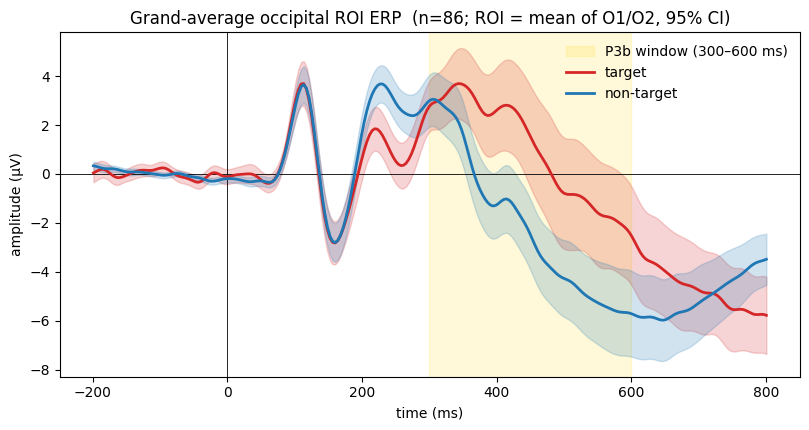

In [4]:
wave = pd.read_csv(WAVE_CSV)
wave = wave[wave["subject"].isin(subs)]
piv  = wave.pivot_table(index=["subject", "channel", "time_ms"],
                        columns="condition", values="amplitude_uv").reset_index()
times = np.sort(piv["time_ms"].unique())

def roi_grand_average(condition):
    # subjects x time matrix of the ROI waveform for one condition
    M = np.full((len(subs), len(times)), np.nan)
    for k, s in enumerate(subs):
        use  = [c for c in ROI if c not in bad_by_sub.get(s, set())]
        rows = piv[(piv["subject"] == s) & (piv["channel"].isin(use))]
        M[k] = rows.groupby("time_ms")[condition].mean().reindex(times).values
    return M

def mean_ci(M):
    n  = np.sum(~np.isnan(M), axis=0)
    m  = np.nanmean(M, axis=0)
    ci = tdist.ppf(0.975, n - 1) * np.nanstd(M, axis=0, ddof=1) / np.sqrt(n)
    return m, ci

mt, ct = mean_ci(roi_grand_average("target"))
mn, cn = mean_ci(roi_grand_average("non_target"))

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.axvspan(*P3B, color="gold", alpha=0.15, label="P3b window (300–600 ms)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
for m, ci, col, lab in [(mt, ct, "#d62728", "target"), (mn, cn, "#1f77b4", "non-target")]:
    ax.plot(times, m, color=col, lw=2, label=lab)
    ax.fill_between(times, m - ci, m + ci, color=col, alpha=0.2)
ax.set_xlabel("time (ms)"); ax.set_ylabel("amplitude (µV)")
ax.set_title(f"Grand-average occipital ROI ERP  (n={len(subs)}; ROI = mean of O1/O2, 95% CI)")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / "grandavg_ROI_target_vs_nontarget.png", dpi=150)
plt.show()

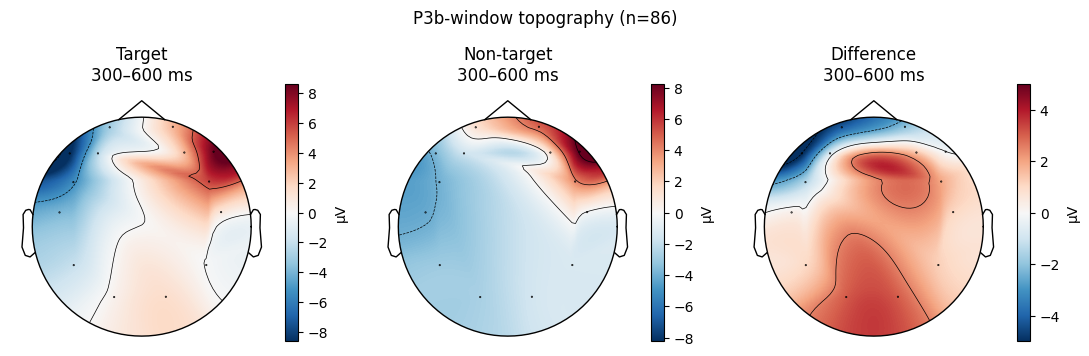

In [5]:
# --- Positive-control topography: target / non-target / difference in the P3b window ---
# Same n=86 analysis sample as the grand-average waveform above. Per-channel P3b-window
# means are read from the ERP summary (no upstream recompute), so the ROI values match Figure 1.
sub_summ = summ[summ["subject"].isin(subs) & summ["channels"].isin(EMOTIV)]
tg   = sub_summ.groupby("channels")["target_p3b_mean_uv"].mean().reindex(EMOTIV)
nt   = sub_summ.groupby("channels")["non_target_p3b_mean_uv"].mean().reindex(EMOTIV)
diff = tg - nt

info = mne.create_info(EMOTIV, sfreq=256.0, ch_types="eeg")
info.set_montage(mne.channels.make_standard_montage("standard_1020"), match_case=False)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, (vals, ttl) in zip(axes, [(tg, "Target"), (nt, "Non-target"), (diff, "Difference")]):
    v = float(np.nanmax(np.abs(vals)))
    im, _ = mne.viz.plot_topomap(vals.values, info, axes=ax, show=False,
                                 cmap="RdBu_r", vlim=(-v, v), contours=4, sensors=True)
    ax.set_title(f"{ttl}\n300–600 ms")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="µV")
fig.suptitle(f"P3b-window topography (n={len(subs)})", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "postcontrol_topo_target_nontarget_diff.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — Correlation topography: social-media composite × P3b

Per channel: Spearman ρ between the composite and the per-subject target-minus-non-target amplitude
in 300–600 ms. Green ring = *p* < .05 (uncorrected); FDR across the 14 channels is reported in the title
and saved in the table.

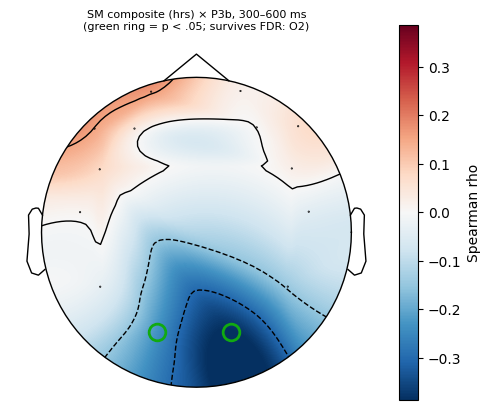

,channel,rho,p,p_fdr
5,P7,-0.035,0.7497,0.9897
6,O1,-0.235,0.0301,0.2109
7,O2,-0.387,0.0002,0.0035
8,P8,-0.144,0.1863,0.5216


In [6]:
def spearman(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = ~(np.isnan(x) | np.isnan(y)); x, y = x[ok], y[ok]; n = len(x)
    r = np.corrcoef(rankdata(x), rankdata(y))[0, 1]
    tval = r * np.sqrt((n - 2) / max(1 - r**2, 1e-12))
    return r, 2 * tdist.sf(abs(tval), n - 2), n

def bh_fdr(p):
    p = np.asarray(p, float); k = len(p); order = np.argsort(p)
    adj = np.empty(k); adj[order] = np.minimum.accumulate((p[order] * k / np.arange(1, k + 1))[::-1])[::-1]
    return np.clip(adj, 0, 1)

rho  = np.full(len(EMOTIV), np.nan)
pval = np.full(len(EMOTIV), np.nan)
for j, ch in enumerate(EMOTIV):
    ch_rows = summ[(summ["channels"] == ch)
                 & (summ["n_target_clean"]   >= MIN_TARGET)
                 & (summ["n_nontarget_clean"] >= MIN_NONTARGET)
                 & ~summ["subject"].isin(manual_excl)].set_index("subject")
    amp = ch_rows["target_minus_non_target_uv"].reindex(subs)
    rho[j], pval[j], _ = spearman(comp.values, amp.values)
pfdr = bh_fdr(pval)

topo_tbl = pd.DataFrame({"channel": EMOTIV, "rho": rho.round(3), "p": pval.round(4), "p_fdr": pfdr.round(4)})
topo_tbl.to_csv(TBL / "corrtopo_composite_p3b.csv", index=False)

info = mne.create_info(EMOTIV, sfreq=256.0, ch_types="eeg")
info.set_montage(mne.channels.make_standard_montage("standard_1020"), match_case=False)
vlim = float(np.nanmax(np.abs(rho)))
fig, ax = plt.subplots(figsize=(5, 4.4))
im, _ = mne.viz.plot_topomap(rho, info, axes=ax, show=False, cmap="RdBu_r", vlim=(-vlim, vlim),
                             sensors=True, mask=pval < 0.05,
                             mask_params=dict(marker="o", markerfacecolor="none",
                                              markeredgecolor="#11aa11", markersize=12, markeredgewidth=2),
                             contours=4)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman rho")
survives = ", ".join(EMOTIV[j] for j in range(len(EMOTIV)) if pfdr[j] < 0.05) or "none"
ax.set_title(f"SM composite (hrs) × P3b, 300–600 ms\n(green ring = p < .05; survives FDR: {survives})", fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "corrtopo_composite_p3b.png", dpi=150)
plt.show()

topo_tbl[topo_tbl.channel.isin(ROI + ["P7", "P8"])]

## Multiple-comparison control — FDR across all 14 channels

The topography tests one correlation per sensor (14 tests), so the false-discovery rate is
controlled with Benjamini–Hochberg. This is the same `p_fdr` already computed for Figure 2,
shown here as a standalone table (sorted by raw *p*). No plot.

In [7]:
fdr_tbl = topo_tbl.sort_values("p").reset_index(drop=True)
fdr_tbl["survives_fdr"] = np.where(fdr_tbl["p_fdr"] < 0.05, "*", "")
print("Channels surviving FDR (q < .05):",
      ", ".join(fdr_tbl.loc[fdr_tbl.p_fdr < 0.05, "channel"]) or "none")
display(fdr_tbl)

Channels surviving FDR (q < .05): O2


,channel,rho,p,p_fdr,survives_fdr
0,O2,-0.387,0.0002,0.0035,*
1,O1,-0.235,0.0301,0.2109,
2,AF3,0.158,0.1474,0.5216,
3,F7,0.148,0.1734,0.5216,
4,P8,-0.144,0.1863,0.5216,
5,FC5,0.074,0.4975,0.9897,
6,F8,0.061,0.5789,0.9897,
7,T8,-0.042,0.6991,0.9897,
8,P7,-0.035,0.7497,0.9897,
9,F3,0.030,0.7818,0.9897,


## k-means usage groups → P3b comparison

Data-driven split of the sample into two social-media-use groups (k-means, k = 2, on the composite),
then the occipital ROI difference wave (target − non-target) is compared between groups with 95% CI.
The a-priori P3b amplitude (300–600 ms) is compared with a Mann–Whitney U test.
(With a single predictor this is close to a median split; k-means just places the cut data-driven.)

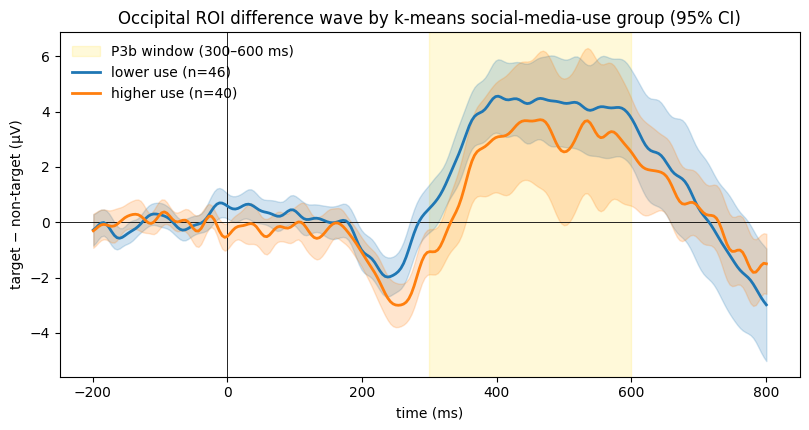

lower use : n=46, P3b median=+2.90 µV
higher use: n=40, P3b median=+1.68 µV
Mann–Whitney U=1218, p=0.0100

[slide boxes] mean difference-wave amplitude in the 300–600 ms window:
  lower use: MEAN = +3.75 µV   (median = +2.90 µV, n=46)
  higher use: MEAN = +2.50 µV   (median = +1.68 µV, n=40)


In [8]:
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu

# k-means on the composite; relabel so group 0 = lower use, 1 = higher use
km    = KMeans(n_clusters=2, random_state=42, n_init=10).fit(comp.values.reshape(-1, 1))
order = np.argsort([comp.values[km.labels_ == c].mean() for c in (0, 1)])
remap = {int(order[0]): 0, int(order[1]): 1}
group = np.array([remap[l] for l in km.labels_])
GLAB  = {0: "lower use", 1: "higher use"}; GCOL = {0: "#1f77b4", 1: "#ff7f0e"}

# per-subject ROI difference wave (target - non-target)
D = np.full((len(subs), len(times)), np.nan)
for k, s in enumerate(subs):
    use = [c for c in ROI if c not in bad_by_sub.get(s, set())]
    g   = (piv[(piv["subject"] == s) & (piv["channel"].isin(use))]
             .groupby("time_ms")[["target", "non_target"]].mean().reindex(times))
    D[k] = (g["target"] - g["non_target"]).values

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.axvspan(*P3B, color="gold", alpha=0.15, label="P3b window (300–600 ms)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
for gj in (0, 1):
    M  = D[group == gj]
    n  = np.sum(~np.isnan(M), axis=0)
    m  = np.nanmean(M, axis=0)
    ci = tdist.ppf(0.975, n - 1) * np.nanstd(M, axis=0, ddof=1) / np.sqrt(n)
    ax.plot(times, m, color=GCOL[gj], lw=2, label=f"{GLAB[gj]} (n={int((group == gj).sum())})")
    ax.fill_between(times, m - ci, m + ci, color=GCOL[gj], alpha=0.2)
ax.set_xlabel("time (ms)"); ax.set_ylabel("target − non-target (µV)")
ax.set_title("Occipital ROI difference wave by k-means social-media-use group (95% CI)")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / "kmeans_group_diffwave_ROI.png", dpi=150)
plt.show()

# compare the a-priori P3b amplitude between groups
p3b_amp = p3b_roi.reindex(subs).values
lo, hi  = p3b_amp[group == 0], p3b_amp[group == 1]
u, pu   = mannwhitneyu(lo, hi, alternative="two-sided")
print(f"lower use : n={len(lo):2d}, P3b median={np.median(lo):+.2f} µV")
print(f"higher use: n={len(hi):2d}, P3b median={np.median(hi):+.2f} µV")
print(f"Mann–Whitney U={u:.0f}, p={pu:.4f}")

# --- group MEAN of the plotted difference wave in the P3b window ---
# These are the numbers shown in the slide boxes ("mean O1/O2 ROI"): they match the height of
# the plotted mean lines above. Note the MEAN differs from the MEDIAN printed above (skewed data):
# report whichever you label on the slide, but keep the label and the value consistent.
_win = (times >= P3B[0]) & (times <= P3B[1])
print("\n[slide boxes] mean difference-wave amplitude in the 300–600 ms window:")
for _gj, _lab in [(0, "lower use"), (1, "higher use")]:
    _gm = np.nanmean(D[group == _gj], axis=0)          # group-average difference wave (the plotted line)
    print(f"  {_lab}: MEAN = {np.nanmean(_gm[_win]):+.2f} µV   (median = {np.median(p3b_amp[group == _gj]):+.2f} µV, n={int((group == _gj).sum())})")

## Target vs non-target ERP by k-means usage group

Same k-means split as above, but drawing each condition (target, non-target) separately
at the O1/O2 ROI instead of the difference wave — one panel per group (lower | higher).
Conditions occupy a taller amplitude range, so the 95% CI band appears smaller than on the
difference-wave figure even though the data and the split are identical. Output:
`figures/kmeans_group_target_nontarget_ROI.png`.

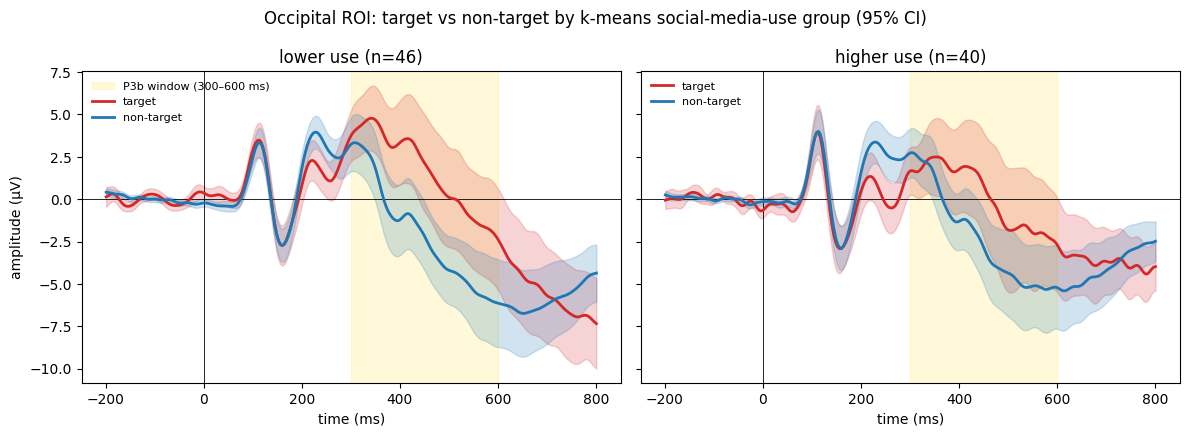

In [9]:
# --- Target vs non-target ERP at the O1/O2 ROI, split by the SAME k-means group ---
# Reuses roi_grand_average(), mean_ci(), and the `group` labels from the cell above.
# Two panels: lower use | higher use. Raw conditions sit on a taller y-axis, so the
# 95% CI band reads smaller than on the difference-wave figure (same data, same split).
CCOL = {"target": "#d62728", "non_target": "#1f77b4"}     # match Figure 1 colours
CLAB = {"target": "target", "non_target": "non-target"}

# subjects x time ROI matrices per condition (computed once), then split by group
M_cond = {c: roi_grand_average(c) for c in ("target", "non_target")}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, gj in zip(axes, (0, 1)):
    sel = group == gj
    ax.axvspan(*P3B, color="gold", alpha=0.15,
               label="P3b window (300–600 ms)" if gj == 0 else None)
    ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
    for cond in ("target", "non_target"):
        m, ci = mean_ci(M_cond[cond][sel])
        ax.plot(times, m, color=CCOL[cond], lw=2, label=CLAB[cond])
        ax.fill_between(times, m - ci, m + ci, color=CCOL[cond], alpha=0.2)
    ax.set_xlabel("time (ms)")
    ax.set_title(f"{GLAB[gj]} (n={int(sel.sum())})")
    ax.legend(frameon=False, loc="upper left", fontsize=8)
axes[0].set_ylabel("amplitude (µV)")
fig.suptitle("Occipital ROI: target vs non-target by k-means social-media-use group (95% CI)")
fig.tight_layout()
fig.savefig(FIG / "kmeans_group_target_nontarget_ROI.png", dpi=150, bbox_inches="tight")
plt.show()

## Epoch retention

Retention for the analysis sample. 200 epochs were presented per subject (40 target + 160 non-target);
`retained_prop` = clean / presented. Every included subject clears the ≥ 20 target and ≥ 80 non-target
inclusion floor.

,overall,target,non_target
mean,0.821,0.817,0.822
std,0.130,0.143,0.132
min,0.520,0.500,0.525
max,1.000,1.000,1.000


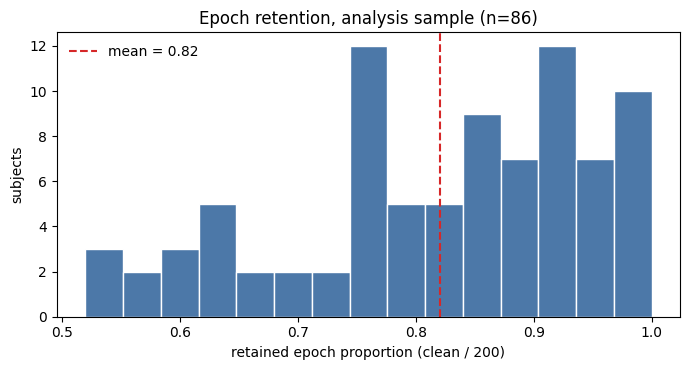

In [10]:
log = (pd.read_csv(PREP / "p3b_erp_processing_log_autoreject_nd_26_allch.csv")
         .set_index("subject").reindex(subs))
retention = pd.DataFrame({
    "overall":    log["retained_prop"],
    "target":     log["n_target_clean"]   / 40,     # 40 target presented
    "non_target": log["n_nontarget_clean"] / 160,    # 160 non-target presented
})
retention.to_csv(TBL / "epoch_retention.csv")
display(retention.describe().loc[["mean", "std", "min", "max"]].round(3))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(retention["overall"], bins=15, color="#4C78A8", edgecolor="white")
ax.axvline(retention["overall"].mean(), color="#d62728", ls="--",
           label=f"mean = {retention['overall'].mean():.2f}")
ax.set_xlabel("retained epoch proportion (clean / 200)"); ax.set_ylabel("subjects")
ax.set_title(f"Epoch retention, analysis sample (n={len(subs)})")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / "epoch_retention.png", dpi=150)
plt.show()

## Provenance

- **Sources:** `p3b_erp_summary_autoreject_nd_26_allch.csv` (scalar P3b amplitudes → correlation),
  `p3b_erp_waveforms_allch_autoreject_nd_26.csv` (time-course → ERP figure),
  `phone_social_media.tsv` (usage bands), `manual_channel_qc_nd26.csv` (exclusions).
- **Consistency:** the occipital ROI correlation reproduces the R primary analysis (ρ ≈ −0.33, *n* = 86).
- **Outputs:** `figures_tables_erp_corrtopo_composite/figures/` and `.../tables/`.